###Context
The rapid growth of data collection has led to a new era of information. Data is being used to create more efficient systems and this is where **Recommendation Systems** come into play. Recommendation Systems are a type of **information filtering systems** as they improve the quality of search results and provides items that are most relevant to the search item or are related to the search history of the user.

They are used to predict the **rating** or **preference** that a use would give to an item. Almost every major tech company has applied them in some form or the other:
* Amazon uses it to suggest products to customers
* YouTube uses it to decide which video to play next on autoplay
* Facebook uses it to recommend people to follow and pages to like.
* Netflix and Spotify depend highly on the effectiveness of their recommendation engines for their business and success

Types of Recommender Systems:
* **Demographic Filtering:** Offer generalized recommendations to every user bsaed on movie popularity and/or genre. The system recommends the same movies to users with similar demographic features. Since each user is different, this approach is considered too simple. The basic idea behinf this system is that movies that are more popular and critically acclaimed will have a higher probability of being liked by the average audience.
* **Content Based Filtering:** They suggest similar items based on a particular item. This system uses item metadata, such as genre, director, description, actors etc. for movies, to make these recommendations. The general idea behind content based filtering is that if a person liked a particular item, then he/she will also like an item that is similar to it.
* **Collaborative Filtering:** This system matches persons with similar interests and provides recommendations based on this matching. Collaborative filters doesn't require item metadata unlike its content-based counterparts.

###Data Loading

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
credit_data = pd.read_csv('/content/drive/MyDrive/Case Studies/Netflix/datasets/tmdb_5000_credits.csv')
movie_data = pd.read_csv('/content/drive/MyDrive/Case Studies/Netflix/datasets/tmdb_5000_movies.csv')

In [ ]:
df1 = credit_data.copy()
df2 = movie_data.copy()

The first dataset contains the following features:
* movie_id - unique identifier for each movie
* cast - name of lead and supporting actors
* crew - name of Director, Editor, Composure, Writer

The second dataset has the following features:
* budget - budget in which the movie was made
* genre - genre of the movie (Action, Comedy, Thriller)
* homepage - link to the homepage of the movie
* id - this is the movie_id in the first dataset
* keywords - keywords or tags related to the movie
* original_language - language in which the movie was made
* origin_title - title of the movie before translation or adaptation
* overview - brief description of the movie
* popularity - numeric quantity specifying the movie popularity
* production_companies - production house of the movie
* production_countries - country in which it was produced
* release_date - date on which it was released
* revenue - worldwide revenue generated by the movie
* runtime - running time of the movie in minutes
* status - "Released" or "Rumored"
* tagline - movie's tagline
* title - title of the movie
* vote_average - average ratings the movie recieved
* vote_count - count of votes received

In [ ]:
df1.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
df2.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
#Let's join the two dataset on "id" column
df1.columns = ['id', 'title', 'cast', 'crew']
df2 = df2.merge(df1, on='id')

In [ ]:
#Quick look at the merged data
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

###Demographic Filtering
Before getting started with this:
* we need a metric to score or rate a movie
* calculate the score for every movie
* sort the scores and recommend the best rated movie to the user

We can use the average ratings of the movie as a score but using this won't be fair enough since a movie with 8.9 avg rating and only 3 votes cannot be considered better than a movie with 7.8 avg rating with 40 votes.
So we'll be using IMdb's **weighted rating** which is given as:
$$WeightedRating(WR) = (\frac{v}{v+m}.R)+(\frac{m}{v+m}.C)$$
where,
* v is the number of votes for the movie
* m is the minimum number of votes required to be listed in the chart
* R is the avg rating of the movie
* C is the mean vote across the whole report

We already have **v**(vote_count) and **R**(vote_average) and C can be calculated as

In [ ]:
C = df2['vote_average'].mean()
C

np.float64(6.092171559442016)

So, the mean rating for all the movies is approx 6 on a scale of 10.

Next step is to determine an appropriate value for **m**(the minimum votes required to be listed in the chart).

We'll use the 90th percentile as our cutoff. In other words, for a movie to feature in charts, it must have more votes than atleast 90% of the movies in the list


In [ ]:
m = df2['vote_count'].quantile(0.9)
m

np.float64(1838.4000000000015)

In [ ]:
#Now we can filter out the movies that qualify for the chart
q_movies = df2.copy().loc[df2['vote_count'] >= m]
q_movies.shape

(481, 23)

We see that there are 481 movies which qualify to be in the list. Now we need to calculate the **weighted_rating** metric for each qualified movie.

For doing this we'll define a function and define a new feature **score**, of which we'll calculate the value by applying this function to our Dataframe of qualified movies.

In [ ]:
def weighted_rating(x, m=m, C=C):
  v = x['vote_count']
  R = x['vote_average']

  return (v/(v+m)*R) + (m/(v+m)*C)

In [ ]:
#Define a new feature 'score' and calculate its value with the weighted_rating function
q_movies['score'] = q_movies.apply(weighted_rating,axis=1)

In [ ]:
#Let's sort the movies based on the score feature
q_movies = q_movies.sort_values('score',ascending=False)

#Output the title, vote count, vote average and score of the top 15 movies
q_movies[['title_x','vote_count','vote_average','score']].head(15)

,title_x,vote_count,vote_average,score
1881,The Shawshank Redemption,8205,8.5,8.059258
662,Fight Club,9413,8.3,7.939256
65,The Dark Knight,12002,8.2,7.920020
3232,Pulp Fiction,8428,8.3,7.904645
96,Inception,13752,8.1,7.863239
3337,The Godfather,5893,8.4,7.851236
95,Interstellar,10867,8.1,7.809479
809,Forrest Gump,7927,8.2,7.803188
329,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
1990,The Empire Strikes Back,5879,8.2,7.697884


And with that, we've made our first basic recommender.

Under the **Trending Now** tab of these systems we find those movies which are very popular and they can be obtained by sorting the dataset by the popularity column

Text(0.5, 1.0, 'Popular Movies')

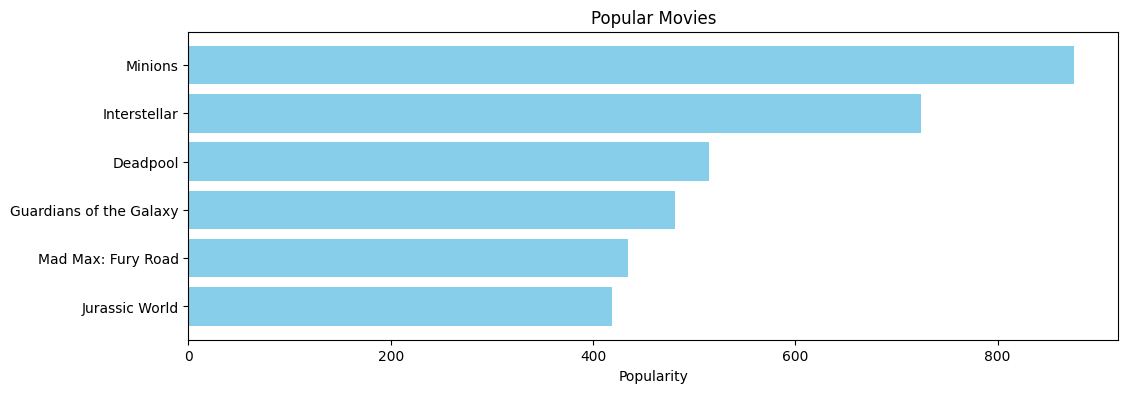

In [ ]:
import matplotlib.pyplot as plt

popular = df2.sort_values('popularity',ascending=False)
plt.figure(figsize=(12,4))
plt.barh(popular['title_x'].head(6),popular['popularity'].head(6),align='center',color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Popularity')
plt.title('Popular Movies')

Just something to keep in mind that these dempgraphic recommender provide a general chart of recommended movies to all the users. They are not sensitive to interests and taste of a particular user. This is when we move on to a more refined system Content-based Filtering.

###Content Based Filtering
Here the content of thr movie(overview,cast,crew,keyword,tagline) is used to find its similarity with other movies. Then the movies that are most likely to be similar are recommended.

####Plot-description based recommender
We'll compute pairwise similarity scores for all movies based on their plot descriptions and recommend movies based on that similarity score.

Plot description is given in the **overview** feature of the dataset

In [ ]:
df2['overview'].head()

,overview
0,"In the 22nd century, a paraplegic Marine is di..."
1,"Captain Barbossa, long believed to be dead, ha..."
2,A cryptic message from Bond’s past sends him o...
3,Following the death of District Attorney Harve...
4,"John Carter is a war-weary, former military ca..."


Here, we have to convert the word vector of each overview.

We'll compute the Term Frequency - Inverse Document Frequency (TF-IDF) vectors for each overview

* Term Frequency(TF) → relative frequency of word in a document ; computed as (term instances / total instances)
* Inverse Documented Frequency (IDF) → relative count of documents containing the term ; computed as log(number of documents / documents with term)

TF*IDF → overall importance of each word to the documents in which they appear

And, this will give us a matrix where:
* each column → a word in the overview vocabulary (i.e. all the words that appear in atleast one document)
* each row → a movie

This is done to reduce the imortance of words that occur frequently in plot overview

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

df2['overview'] = df2['overview'].fillna('')

tfidf_matrix = tfidf.fit_transform(df2['overview'])

tfidf_matrix.shape

(4803, 20978)

See that, over 20000 words were used to describe 4800 movies in our dataset.

With this matrix in hand, we can compute a similarity score. There's euclidean, Pearson and cosine similarity scores, there's no right answer to which one is the best. Different scores work well in different scenarios and its often a good idea to experiment with scores.

We'll be using **cosine similarity score** to calculate a numerc quantity that denotes the similarity between two movies.

We use it since it is independent of magnitude and it is relatively easy and fast to calculate

$$similarity=cos(θ)=\frac{A.B}{||A||.||B||}=\frac{∑A_iB_i}{\sqrt{A_i^2}\sqrt{B_i^2}}$$
Since we have the TF-IDF vectorizer, calculating the dot product will directly give us the cosine similarity score. Thus, we'll use linear_kernel() since it's faster

In [ ]:
from sklearn.metrics.pairwise import linear_kernel

cosine_sim = linear_kernel(tfidf_matrix,tfidf_matrix)

Define a function that takes movie title as an input and outputs a list of top 10 similar movies . For this, we need a reverse mapping of movie titles and Dataframe indices i.e. we need a mechanism to identify the index of a movie in our metadata Dataframe, given its title.

In [ ]:
#Construct a reverse map of indices and movie titles
indices = pd.Series(df2.index, index=df2['title_x']).drop_duplicates()

* Get the index of the movie given its title.
* Get the list of cosine similarity scores for that particular movie with all the movies. Convert it into a list of tuples where the first element is its position and second element is its similarity score.
* Sort the above-mentioned list of tuples based on similarity score, i.e. the second element
* Get the top 10 elements of the list. Ignore the first element since it refers to itself (the movie most similar to a particular movie is the movie itself)
* Return the titles corresponding to the indices of the top elements

In [ ]:
def get_recommendations(title, cosine_sim = cosine_sim):
  idx = indices[title] #index of the movie that matches with the title

  sim_score= list(enumerate(cosine_sim[idx])) #pairwise similarity scores of all movie with that movie

  sim_scores = sorted(sim_score, key= lambda x: x[1], reverse= True) #sort movies based on similarity scores

  sim_scores = sim_scores[1:11] #get the scores of 10 most similar movies

  movie_indices =[i[0] for i in sim_scores] #get the movie indices

  return df2['title_x'].iloc[movie_indices] #return the top 10 most similar movies

In [ ]:
get_recommendations('The Dark Knight Rises')

,title_x
65,The Dark Knight
299,Batman Forever
428,Batman Returns
1359,Batman
3854,"Batman: The Dark Knight Returns, Part 2"
119,Batman Begins
2507,Slow Burn
9,Batman v Superman: Dawn of Justice
1181,JFK
210,Batman & Robin


In [ ]:
get_recommendations('The Avengers')

,title_x
7,Avengers: Age of Ultron
3144,Plastic
1715,Timecop
4124,This Thing of Ours
3311,Thank You for Smoking
3033,The Corruptor
588,Wall Street: Money Never Sleeps
2136,Team America: World Police
1468,The Fountain
1286,Snowpiercer


Our system has done a decent job if finding movies with similar plot descriptions, but the quality of recommendations is not that great.

The Dark Knight Rises returns all the other Batman movies while it is more likely that the people who liked that movie are more inclined to enjoy Christopher Nolan movies.

####Credits, Genres and Keywords based Recommender
Quality of recommender increases with the better usage of metadata.

We're going to build a recommender based on the following metadata: top 3 actors, director, related genres and movie plot keywords.

From the **cast**, **crew** and **keywords** features, we need to extract the three most important actors, the director and the keywords associated with that movie.
Right now our data is present in the form of list of strings but we'll need to convert it into a safe and usable structure

In [ ]:
#Parse the features into corresponding Python objects
from ast import literal_eval

features = ['cast','crew','keywords','genres']

for feature in features:
  df2[feature] = df2[feature].apply(literal_eval)

In [ ]:
#get the director's name from the crew feature. If not present then return NaN

def get_director(x):
  for i in x:
    if i['job'] == 'Director':
      return i['name']
  return np.nan

In [ ]:
#Return the list of top 3 elemens or the entire list, whicheevr is more
def get_list(x):
  if isinstance(x,list):
    names = [i['name'] for i in x]

    if len(names) > 3:
      names = names[:3]
    return names

  return []

In [ ]:
#Define new director, cast, genres and keywords that are in suitable form

df2['director'] = df2['crew'].apply(get_director)

features = ['cast','keywords','genres']
for feature in features:
  df2[feature] = df2[feature].apply(get_list)

Make sure that the vectorizer doesn't count the Johnny of "Johnny Depp" and "Johnny Galecki" as the same.

Thus, we'll convert the names and keywords instances into lowercase and strip all the spaces between them

In [ ]:
#Convert all strings to lowercase and strips names of spaces
def clean_data(x):
  if isinstance(x,list):
    return [str.lower(i.replace(" ","")) for i in x]
  else:
      if isinstance(x,str):
        return str.lower(x.replace(" ",""))
      else:
        return ''

In [ ]:
#Applying thr function to our features
features = ['cast','keywords','director','genres']

for feature in features:
  df2[feature] = df2[feature].apply(clean_data)

Create a "**metadata soup**" i.e. a string that contains all the metadata that we want to feed our vectorizer (namely actors, directors and keywords)

In [ ]:
def create_soup(x):
  keywords = x['keywords'] if isinstance(x['keywords'], list) else []
  cast = x['cast'] if isinstance(x['cast'], list) else []
  director = x['director'] if isinstance(x['director'], str) else ''
  genres = x['genres'] if isinstance(x['genres'], list) else []

  return ' '.join(keywords) + ' ' + ' '.join(cast) + ' ' + director + ' ' + ' '.join(genres)

df2['soup'] = df2.apply(create_soup, axis=1)

The only difference from demographic filtering is that we'll be using `CountVectorizer()` instead of TF-IDF, because we do not want to down-weight the presence of actor/director if he or she has acted/directed in relatively more movies. It doesn't make much intuitive sense

In [ ]:
#Create the count matrix
from sklearn.feature_extraction.text import CountVectorizer

count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(df2['soup'])

In [ ]:
#Compute cosine similarity matrix based on count matrix
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim2 = cosine_similarity(count_matrix, count_matrix)

In [ ]:
#reset index of main dataframe and construct reverse mapping as before
df2 = df2.reset_index()
indices = pd.Series(df2.index, index = df2['title_x'])

In [ ]:
get_recommendations('The Dark Knight Rises',cosine_sim2)

,title_x
65,The Dark Knight
119,Batman Begins
4638,Amidst the Devil's Wings
1196,The Prestige
3073,Romeo Is Bleeding
3326,Black November
1503,Takers
1986,Faster
303,Catwoman
747,Gangster Squad


In [ ]:
get_recommendations('The Avengers',cosine_sim2)

,title_x
7,Avengers: Age of Ultron
26,Captain America: Civil War
79,Iron Man 2
169,Captain America: The First Avenger
174,The Incredible Hulk
85,Captain America: The Winter Soldier
31,Iron Man 3
33,X-Men: The Last Stand
68,Iron Man
94,Guardians of the Galaxy


See that our recommender has been able o capture more information due to more metadata and has given us arguable better recommenations. It is more likely that Marvels or DC comics fans will like the movies of the same production house. Therefore, to our features above we can add production_company . We can also increase the weight of the director , by adding the feature multiple times in the soup.

###Collaborative Filtering
Content-based engine is only capable of suggesting movies which are close to a certain movie, its not capable of capturing tastes and providing recommendations across genres

Also the engine is not really personal in that it doesn't capture the personal tase and biases of the user. Anyone querying our engine for recommendations based on a movie will receive the same recommendations for that movie, regardless of who she/he is.

We'll be using Collaborative Filtering to fix this issue. There're mainly two types:
* **User-based Filtering**: recommend products to a user that similar users have liked. For measuring the similarity between two users we can use pearson correlation or cosine similarity. Although computing user-based CF is very simple, it suffers from several problems. One main issue is that users’ preference can change over time. It indicates that precomputing the matrix based on their neighboring users may lead to bad performance. To tackle this problem, we can apply item-based CF.
* **Item-based Filtering**: Instead of measuring the similarity between users, the item-based CF recommends items based on their similarity with the items that the target user rated. Likewise, the similarity can be computed with Pearson Correlation or Cosine Similarity. The major difference is that, with item-based collaborative filtering, we fill in the blank vertically, as oppose to the horizontal manner that user-based CF does.  However, several problems remain for this method. First, the main issue is ***scalability***. The computation grows with both the customer and the product. The worst case complexity is O(mn) with m users and n items. In addition, **sparsity** is another concern.

####Singular Value Decomposition
One way to handle the scalability and sparsity issue created by CF is to leverage a **latent factor model** to capture the similarity between users and items. Essentially, we want to turn the recommendation problem into an optimization problem. We can view it as how good we are in predicting the rating for items given a user. One common metric is Root Mean Square Error (RMSE). **The lower the RMSE, the better the performance.**

**latent factor** → is a broad idea which describes a property or concept that a user or an item have. For instance, for music, latent factor can refer to the genre that the music belongs to. SVD decreases the dimension of the utility matrix by extracting its latent factors. Essentially, we map each user and each item into a latent space with dimension r. Therefore, it helps us better understand the relationship between users and items as they become directly comparable

To implement Collaborative Filtering we'll need to use a dataset that has User ID, which is essential. We'll be working with another dataset.

In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2610411 sha256=da69ac37438b04a15815f1f0bda1dec737cb2a2f4d28e90939e6cc902de0cc9a
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
from surprise import Reader, Dataset, SVD, evaluate
reader = Reader()
ratings = pd.read_csv('/content/drive/MyDrive/Case Studies/Netflix/datasets/ratings_small.csv')
ratings.head()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

ImportError: numpy.core.multiarray failed to import (auto-generated because you didn't call 'numpy.import_array()' after cimporting numpy; use '<void>numpy._import_array' to disable if you are certain you don't need it).

Note that in this dataset, the movies are rated out of 5 unlike the earlier one

In [ ]:
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
data.split(n_folds=5)

In [ ]:
svd = SVD()
evaluate(svd, data, measures=['RMSE', 'MAE'])

We get a mean Root Mean Sqaure Error of 0.89 approx which is more than good enough for our case. Let us now train on our dataset and arrive at predictions.

In [ ]:
trainset = data.build_full_trainset()
svd.fit(trainset)

Let us pick user with user Id 1 and check the ratings she/he has given.

In [ ]:
ratings[ratings['userId'] == 1]

In [ ]:
svd.predict(1, 302, 3)

For movie with ID 302, we get an estimated prediction of 2.618. One startling feature of this recommender system is that it doesn't care what the movie is (or what it contains). It works purely on the basis of an assigned movie ID and tries to predict ratings based on how the other users have predicted the movie.

In [ ]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 43.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
